# Monte Carlo equity: convergence and uncertainty

This notebook demonstrates two ideas behind the equity engine in this repo:

1. **Convergence.** A Monte Carlo equity estimate converges to the true value as
   the number of simulations grows, and we can draw a shrinking confidence band
   around it.
2. **Standard-error scaling.** The error of a Monte Carlo estimate falls like
   $1/\sqrt{N}$ — quadrupling the sample size halves the error.

The running example is the classic preflop cooler **AA vs KK**, whose true
equity for the aces is well known to be about **0.8217**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from poker.equity import equity, equity_curve

TRUE_AA_VS_KK = 0.8217  # accepted value for AA vs KK preflop (aces' equity)
plt.rcParams["figure.figsize"] = (9, 5)

## 1. A single estimate with its confidence interval

`equity` returns the point estimate together with a standard error and a 95%
confidence interval. The true value should sit inside the interval.

In [2]:
res = equity("AsAh", "KsKh", n=50_000, seed=1)
print(res)
print(f"true value {TRUE_AA_VS_KK} inside 95% CI: "
      f"{res.ci_low <= TRUE_AA_VS_KK <= res.ci_high}")

equity 0.8248 +/- 0.0017 (95% CI [0.8215, 0.8281], n=50000)
true value 0.8217 inside 95% CI: True


## 2. Convergence of the running estimate

`equity_curve` exposes the cumulative estimate after each sample, along with a
$\pm 1.96\,\text{SE}$ band. As $N$ grows the estimate settles onto the true
value and the band tightens.

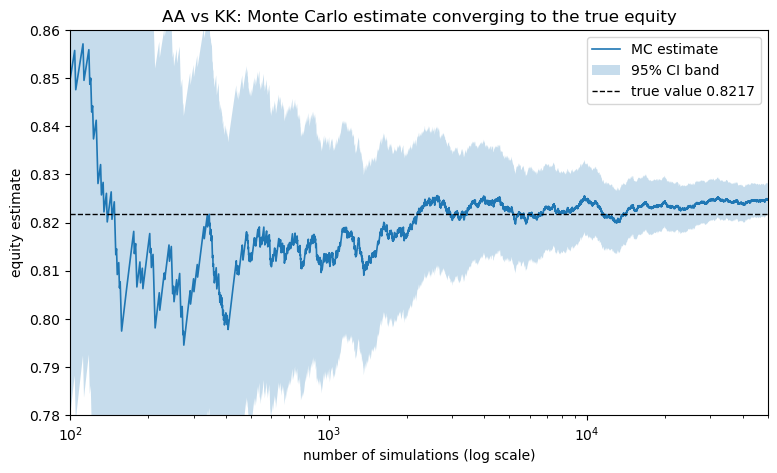

In [3]:
counts, est, half = equity_curve("AsAh", "KsKh", n=50_000, seed=1)

fig, ax = plt.subplots()
ax.plot(counts, est, lw=1.2, label="MC estimate")
ax.fill_between(counts, est - half, est + half, alpha=0.25, label="95% CI band")
ax.axhline(TRUE_AA_VS_KK, color="black", ls="--", lw=1, label="true value 0.8217")
ax.set_xscale("log")
ax.set_xlim(100, counts[-1])
ax.set_ylim(0.78, 0.86)
ax.set_xlabel("number of simulations (log scale)")
ax.set_ylabel("equity estimate")
ax.set_title("AA vs KK: Monte Carlo estimate converging to the true equity")
ax.legend()
plt.show()

## 3. Standard error scales like $1/\sqrt{N}$

The half-width of the confidence band is $1.96\,\text{SE}$, so the standard
error is `half / 1.96`. Plotted against $N$ on log-log axes it is a straight
line of slope $-1/2$. We fit the slope to confirm.

fitted log-log slope: -0.504  (theory: -0.5)


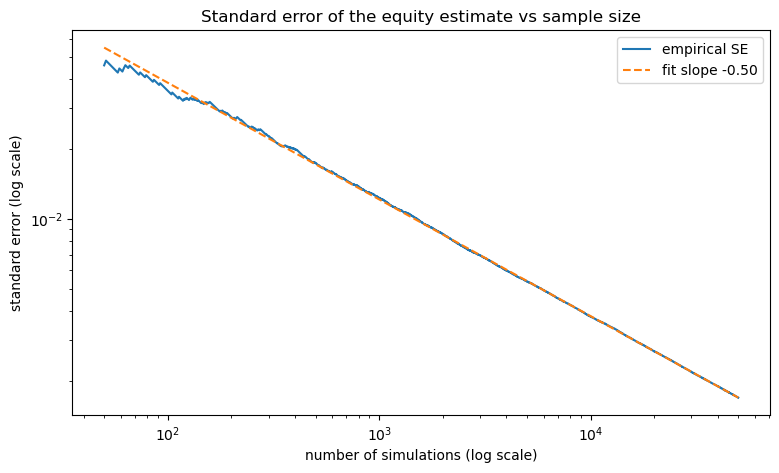

In [4]:
se = half / 1.96
# Skip the noisy first few samples for the fit.
mask = counts >= 50
slope, intercept = np.polyfit(np.log(counts[mask]), np.log(se[mask]), 1)
print(f"fitted log-log slope: {slope:.3f}  (theory: -0.5)")

fig, ax = plt.subplots()
ax.loglog(counts[mask], se[mask], label="empirical SE")
ax.loglog(counts[mask], np.exp(intercept) * counts[mask] ** slope, ls="--",
          label=f"fit slope {slope:.2f}")
ax.set_xlabel("number of simulations (log scale)")
ax.set_ylabel("standard error (log scale)")
ax.set_title("Standard error of the equity estimate vs sample size")
ax.legend()
plt.show()

## 4. Cross-check against exact enumeration

On a board where few cards remain, we can enumerate every outcome exactly and
confirm the Monte Carlo estimate agrees within its confidence interval.

In [5]:
from poker.equity import equity_exact

board = "2c7d9hQs"  # four board cards known -> only the river varies
ex = equity_exact("AsAh", "KsKh", board=board)
mc = equity("AsAh", "KsKh", board=board, n=20_000, seed=2)
print("exact:", ex)
print("MC:   ", mc)
print(f"exact value inside MC 95% CI: {mc.ci_low <= ex.equity <= mc.ci_high}")

exact: equity 0.9545 (exact, 44 outcomes)
MC:    equity 0.9544 +/- 0.0015 (95% CI [0.9515, 0.9572], n=20000)
exact value inside MC 95% CI: True


## 5. From equity to a decision: a push/fold chart

Equity feeds the bot's expected-value reasoning. The heads-up open-shove range
(`#` = shove, `.` = fold) depends on the stack: at a deep stack only strong hands
are profitable shoves, and the range **widens as the stack shortens**. Below we
print it at 40bb and 20bb.

This assumes a *fixed* villain calling range. Because that range is fairly tight
(~22% of hands), the steal succeeds often, so the shove range keeps widening at
shorter stacks until — by about 12bb — every hand is a profitable shove and the
chart is fully saturated (which is why a single short-stack chart can't show the
widening).

**Reading the grid.** It uses the standard 13x13 starting-hand layout: the
**diagonal** is pocket pairs (AA, KK, ... 22), the **upper-right triangle** is
*suited* hands (e.g. AKs), and the **lower-left triangle** is the *offsuit*
hands (e.g. AKo). So the grid is **not symmetric about the diagonal** by design:
a cell and its mirror are different hands — suited above, offsuit below.

In [6]:
from poker.bot import format_pushfold_grid, pushfold_range

CALL = "22+, A2s+, A7o+, K9s+, KTo+, QTs+, JTs"
for stack in (40, 20):
    chart = pushfold_range(stack, CALL, n=4_000, seed=0)
    n_push = sum(d.action == "push" for d in chart.values())
    print(f"=== {stack}bb: shoving {n_push}/169 starting hands ===")
    print(format_pushfold_grid(chart))
    print()

=== 40bb: shoving 32/169 starting hands ===
   A K Q J T 9 8 7 6 5 4 3 2
A  # # # # # # # # # # # . .
K  # # # # . . . . . . . . .
Q  # # # . . . . . . . . . .
J  # . . # . . . . . . . . .
T  # . . . # . . . . . . . .
9  # . . . . # . . . . . . .
8  # . . . . . # . . . . . .
7  # . . . . . . # . . . . .
6  . . . . . . . . # . . . .
5  . . . . . . . . . # . . .
4  . . . . . . . . . . # . .
3  . . . . . . . . . . . # .
2  . . . . . . . . . . . . .



=== 20bb: shoving 92/169 starting hands ===
   A K Q J T 9 8 7 6 5 4 3 2
A  # # # # # # # # # # # # #
K  # # # # # # # # # # # # .
Q  # # # # # # # # # # # . .
J  # # # # # # # # # # . . .
T  # # # # # # # # # . . . .
9  # # # # # # # # # # . . .
8  # # # . # # # # # # . . .
7  # # . . . # . # # # . . .
6  # . . . . . . . # # . . .
5  # . . . . . . . . # . # .
4  # . . . . . . . . . # . .
3  # . . . . . . . . . . # .
2  # . . . . . . . . . . . #



Because suited hands can make flushes they have more equity than their
offsuit twins, so the upper (suited) triangle is systematically denser than the
lower (offsuit) one — for example at 40bb **KJs** is a shove while **KJo** is a
fold. That is the asymmetry you see, and it is the intended behaviour, not a bug.

A second, cosmetic source of irregularity is **Monte Carlo noise**: each cell's
equity-when-called is estimated from a finite sample (`n` simulations), so hands
sitting right at the EV threshold can flip on sampling luck. That is what
produces any ragged edges or a stray lone `#` deep in the fold region. Raising
`n` smooths those out (we use `n=4000` here); the suited/offsuit asymmetry above
is structural and remains at any sample size.